In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
lexicon = pd.read_csv("/mnt/ssd_1/ivn/lm-confidence-evaluation-harness/linguistic_confidence_lexicon/hedging_word_scores.csv")
lexicon

,hedging_word,all_scores,count,mean,std,alpha_param,beta_param
0,I am almost sure,"[0.7, 0.5, 0.7, 0.9, 0.3, 0.4, 0.6, 0.3, 0.3, ...",491,0.666415,0.198612,2.233129,1.081462
1,I am certain,"[0.9, 0.95, 0.95, 0.9, 0.95, 0.95, 1.0, 1.0, 0...",523,0.811205,0.271211,0.410787,0.207534
2,I am confident that,"[1.0, 1.0, 1.0, 0.9, 0.9, 0.9, 0.9, 0.9, 1.0, ...",522,0.703008,0.233378,0.910526,0.471482
3,I am convinced,"[1.0, 0.95, 0.95, 0.85, 0.9, 0.8, 0.8, 0.9, 0....",492,0.759146,0.252197,0.648560,0.385909
4,I am doubtful,"[0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, 0.2, ...",530,0.331830,0.178113,1.731108,3.489750
...,...,...,...,...,...,...,...
637,without doubt,"[0.7, 0.7, 0.7, 0.8, 0.8, 1.0, 1.0, 0.9, 0.95,...",500,0.896400,0.115668,3.665004,0.412903
638,without question,"[1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.95, 0.0, 1.0,...",551,0.929782,0.110989,1.840769,0.222047
639,would,"[0.8, 0.7, 0.7, 0.7, 0.7, 0.3, 0.6, 0.6, 0.45,...",488,0.658934,0.187903,2.372313,1.213342
640,would appear to,"[0.45, 0.6, 0.5, 0.5, 0.3, 1.0, 0.6, 0.5, 0.6,...",594,0.578401,0.169973,3.472961,2.578178


In [3]:
lexicon.columns

Index(['hedging_word', 'all_scores', 'count', 'mean', 'std', 'alpha_param',
       'beta_param'],
      dtype='str')

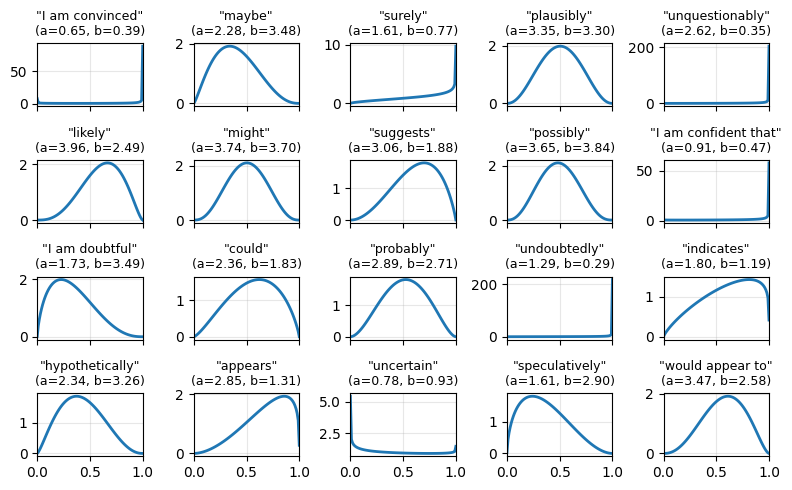

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from math import lgamma, exp

valid_lexicon = lexicon.dropna(subset=["hedging_word", "alpha_param", "beta_param"])

selected_words = ["maybe", "probably", "possibly", "could", "might", "uncertainty", "sure", "seems", "appears", 
                  "suggests", "indicates", "likely", "guess", "assume", "uncertain", "surely", 
                  "undoubtedly", "unquestionably", "hypothetically", "would appear to", "I am convinced",
                  "I am confident that", "I am doubtful", "plausibly", "speculatively"]

sampled = valid_lexicon[valid_lexicon["hedging_word"].isin(selected_words)].sample(n=min(25, len(valid_lexicon[valid_lexicon["hedging_word"].isin(selected_words)])))

x = np.linspace(1e-4, 1 - 1e-4, 100)

def beta_pdf(x_vals, alpha, beta):
    # Beta(a, b) PDF = x^(a-1) * (1-x)^(b-1) / B(a, b)
    log_B = lgamma(alpha) + lgamma(beta) - lgamma(alpha + beta)
    return (x_vals ** (alpha - 1)) * ((1 - x_vals) ** (beta - 1)) / exp(log_B)

fig, axes = plt.subplots(4, 5, figsize=(8, 5), sharex=True)
axes = axes.flatten()

for ax, row in zip(axes, sampled.itertuples(index=False)):
    a = float(row.alpha_param)
    b = float(row.beta_param)
    y = beta_pdf(x, a, b)

    ax.plot(x, y, linewidth=2)
    ax.set_title(f""""{row.hedging_word}"\n(a={a:.2f}, b={b:.2f})""", fontsize=9)
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.3)

for ax in axes[len(sampled):]:
    ax.axis("off")

# fig.suptitle("Beta Distributions for Randomly Sampled Hedging Words", fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig("hedging_word_beta_distributions.pdf", dpi=300, bbox_inches="tight")